# Pull new metrics from mccray
First based off 'Original Transcript'

In [32]:
import pandas as pd
import numpy as np
import re, nltk, csv, os
from nltk.corpus import words, PlaintextCorpusReader
import matplotlib.pyplot as plt

In [33]:
# pull entire dataset
# df = pd.read_csv("../data/mccray/october_sprint/mccray d_main.csv")
# df = pd.read_csv("../data/mccray/october_sprint/D_{dataset[0:3]}_main_v2.csv")

dataset = "simkins"  # options: mccray, simkins

df = pd.read_csv(f"../data/{dataset}/split_data/h1_split/D_{dataset[0:3]}_h1_main.csv")
# df = pd.read_csv(f"../data/{dataset}/split_data/h2_split/D_{dataset[0:3]}_h2_main.csv")


print(f"df len: {len(df)}")
print(list(df))

# # nltk base
# nltk.download('words')
# english_vocab = set(w.lower() for w in words.words())

# improved ntlk corpus
wordslist = PlaintextCorpusReader('../data/mccray/nltk', 'combined_words_corpus.txt')
english_vocab = set(w.lower() for w in wordslist.words())

def save_csv(df, title):
    df.to_csv(title,
          index=False,
          encoding='utf-8',
          quoting=csv.QUOTE_NONNUMERIC,   
          escapechar='\\',
          lineterminator='\n')

print(len(df))

df len: 11238
['Title', 'Date', 'Source', 'Description', 'Digital Collection', 'Contributing Institution', 'Rights', 'Reference URL', 'CONTENTdm number', 'CONTENTdm file name', 'Year', 'Original Transcript', 'Original Len', 'Issue Types', 'Detected Artifacts', 'D_sim_cleaned_v1', 'sc_v1_len', 'D_sim_cleaned_v2', 'sc_v2_len']
11238


In [34]:
title = 'Title'
descrip = 'Description'

# Function to apply re pattern
def re_pattern(text, pattern):
    text = re.sub(r'\s+', '', str(text))
    if not isinstance(text, str) or len(text) == 0:
        return 0
    total = len(text)
    matches = len(pattern.findall(text))
    return (matches / total) * 100

# patterns
# alphanum_standard = re.compile(r'[a-zA-Z0-9\s.,!?;:\'"()\-_/]')
alphanum_standard = re.compile(r'[a-zA-Z0-9!-/:-@[-`{-~]')
alpha_only = re.compile(r'[a-zA-Z]')

# return percent numeric over total alphanum + standard chars
def percent_num(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0
    total_alphanum = len(alphanum_standard.findall(text))
    if total_alphanum == 0:
        return 0
    total_numeric = len(re.findall(r'[0-9]', text))
    return (total_numeric / total_alphanum) * 100

# common suffixes for trimming
# edit this to account for inflectional and derivational
suffixes = {
    # INFLECTIONAL SUFFIXES
    # Plural forms
    "s": True,
    "es": True,
    "ies": True,      
    "ves": True,      
    
    # Verb forms (tense/aspect)
    "ed": True,       # walk -> walked
    "ing": True,      # walk -> walking
    
    # Comparative/Superlative
    "er": True,       # fast -> faster
    "est": True,      # fast -> fastest
    
    # DERIVATIONAL SUFFIXES (word-forming) 
    # Adjective to Adverb
    "ly": True,       # quick -> quickly
    
    # Adjective/Verb to Noun
    "ness": True,     # happy -> happiness
    "ment": True,     # govern -> government
    "tion": True,     # create -> creation
    "sion": True,     # expand -> expansion
    "ity": True,      # real -> reality
    "ty": True,       # certain -> certainty
    "ance": True,     # perform -> performance
    "ence": True,     # differ -> difference
    "ancy": True,     # vacant -> vacancy
    "ency": True,     # fluent -> fluency
    "dom": True,      # king -> kingdom
    "ship": True,     # friend -> friendship
    "hood": True,     # child -> childhood
    "age": True,      # break -> breakage
    "al": True,       # refuse -> refusal
    "ure": True,      # fail -> failure
    
    # Noun/Verb to adjective
    "ous": True,      # danger -> dangerous
    "ious": True,     # glory -> glorious
    "ful": True,      # care -> careful
    "less": True,     # care -> careless
    "able": True,     # read -> readable
    "ible": True,     # sense -> sensible
    "ive": True,      # act -> active
    "ic": True,       # base -> basic
    "ical": True,     # history -> historical
    "ish": True,      # child -> childish
    "like": True,     # life -> lifelike
    "y": True,        # dirt -> dirty
    
    # Verb-forming
    "ize": True,      # modern -> modernize
    "fy": True,       # class -> classify
    "ate": True,      # active -> activate
    "en": True,       # dark -> darken
    
    # Noun-forming 
    "or": True,       # act -> actor
    "ist": True,      # art -> artist
    "ian": True,      # music -> musician
    "ant": True,      # assist -> assistant
    "ent": True,      # study -> student
}

# english metrics with nltk corpus + additional checks
def english_nltk_metrics(text, vocab):
    """Return dict showing which tokens are recognized or not (NLTK-style regex)."""
    if not isinstance(text, str) or not text.strip() or len(text) == 0:
        return {"valid_words": [], "not_words": [], "word_count": 0, "valid_word_count": 0, "percentage": 0, "total_chars_count_from_valid_words": 0, "number_of_words_gt_3": 0}
    # tokenize text into words (using only alphabetic characters, min length 2)
    tokens = re.findall(r"[A-Za-z]{2,}", text.lower())
    # calculate metrics
    word_count = len(tokens)
    num_words_gt_3 = 0
    valid_words, not_words = [], []
    total_chars_count_from_valid_words = 0
    # check each token
    for t in tokens:      
        if t in vocab: 
            valid_words.append(t)
            total_chars_count_from_valid_words = total_chars_count_from_valid_words + len(t)
            if len(t) > 3:
                num_words_gt_3 += 1
        else:
            found_variant = False
            if len(t) > 3: 
                for i in range(4, 0, -1): # check suffixes of length 4 to 1
                    stem = t[:-i]
                    suffix = t[-i:]
                    if suffixes.get(suffix) and len(stem) >= 3:
                        if stem in vocab or (stem + "y") in vocab or (stem + "e") in vocab:
                            valid_words.append(t)
                            total_chars_count_from_valid_words += len(t)
                            found_variant = True
                            if len(t) > 3:
                                num_words_gt_3 += 1
                            break # exit suffix loop
            if not found_variant:
                not_words.append(t)
    # final calculations
    valid_word_count = len(valid_words)
    if len(tokens) == 0:
        percentage = 0
    else:
        percentage = 100 * len(valid_words) / len(tokens)
    return {"valid_words": valid_words, "not_words": not_words, "word_count":word_count, "valid_word_count":valid_word_count, "percentage": percentage, "total_chars_count_from_valid_words": total_chars_count_from_valid_words, "number_of_words_gt_3": num_words_gt_3}


In [35]:
# Title 
df['% alphanum_standard title'] = df[title].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only title'] = df[title].apply(lambda x: re_pattern(x, alpha_only))
df['% en title'] = df[title].apply(lambda x: english_nltk_metrics(x, english_vocab).get("percentage"))

# Description
df['% alphanum_standard descrip'] = df[descrip].apply(lambda x: re_pattern(x, alphanum_standard))
df['% alpha_only descrip'] = df[descrip].apply(lambda x: re_pattern(x, alpha_only))
df['% en descrip'] = df[descrip].apply(lambda x: english_nltk_metrics(x, english_vocab).get("percentage"))

In [36]:
# Transcripts
og_tr = "Original Transcript"
sc_tr_v1 = f'D_{dataset[0:3]}_cleaned_v1'
sc_tr_v2 = f'D_{dataset[0:3]}_cleaned_v2'

# alphanumeric + ascii symbols
df[f'% alphanum_standard D_{dataset[0:3]}_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alphanum_standard))
df[f'% alphanum_standard D_{dataset[0:3]}_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alphanum_standard))
df[f'% alphanum_standard D_{dataset[0:3]}_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alphanum_standard))

# alphabet a-Z
df[f'% alpha_only D_{dataset[0:3]}_raw tr'] = df[og_tr].apply(lambda x: re_pattern(x, alpha_only))
df[f'% alpha_only D_{dataset[0:3]}_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: re_pattern(x, alpha_only))
df[f'% alpha_only D_{dataset[0:3]}_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: re_pattern(x, alpha_only))

# num 0-9 over alphanumeric + ascii symbols
df[f'% num D_{dataset[0:3]}_raw tr'] = df[og_tr].apply(lambda x: percent_num(x))
df[f'% num D_{dataset[0:3]}_cleaned_v1 tr'] = df[sc_tr_v1].apply(lambda x: percent_num(x))
df[f'% num D_{dataset[0:3]}_cleaned_v2 tr'] = df[sc_tr_v2].apply(lambda x: percent_num(x))

# More advanced word checks
df[['og_valid_words', 'og_not_words', 'og_word_count', 'og_valid_word_count', 'og_percentage', 'og_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[og_tr].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v1_valid_words', 'sc_v1_not_words', 'sc_v1_word_count', 'sc_v1_valid_word_count', 'sc_v1_percentage', 'sc_v1_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[sc_tr_v1].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df[['sc_v2_valid_words', 'sc_v2_not_words', 'sc_v2_word_count', 'sc_v2_valid_word_count', 'sc_v2_percentage', 'sc_v2_total_chars_count_from_valid_words', "number_words_gt_3"]] = df[sc_tr_v2].apply(
    lambda text: pd.Series(english_nltk_metrics(text, english_vocab))
)

df['max_word_count_value'] = df[['og_word_count', 'sc_v1_word_count', 'sc_v2_word_count']].max(axis=1)

# Calculate each version's valid word count as percentage of max
df['% og_valid_words'] = df.apply(
    lambda row: (row['og_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)
df['% sc_v1_valid_words'] = df.apply(
    lambda row: (row['sc_v1_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)
df['% sc_v2_valid_words'] = df.apply(
    lambda row: (row['sc_v2_valid_word_count'] / row['max_word_count_value'] * 100) 
    if row['max_word_count_value'] != 0 else 0, axis=1
)

# Calculate Chars in Valid Words Percentage (valid word chars / total char count)
df['og_valid_words_char_percentage'] = df.apply(
    lambda row: (row['og_total_chars_count_from_valid_words'] / row['Original Len'] * 100) 
    if row['Original Len'] != 0 else 0, axis=1
)
df['sc_v1_valid_words_chars_percentage'] = df.apply(
    lambda row: (row['sc_v1_total_chars_count_from_valid_words'] / row['sc_v1_len'] * 100) 
    if row['sc_v1_len'] != 0 else 0, axis=1
)
df['sc_v2_valid_words_chars_percentage'] = df.apply(
    lambda row: (row['sc_v2_total_chars_count_from_valid_words'] / row['sc_v2_len'] * 100) 
    if row['sc_v2_len'] != 0 else 0, axis=1
)

# Calculate Chars in Valid Words Percentage (valid word chars / alpha only chars count)
df['og_alpha_count'] = df[og_tr].apply(lambda x: len(alpha_only.findall(str(x))))
df['og_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['og_total_chars_count_from_valid_words'] / row['og_alpha_count'] * 100) 
    if row['og_alpha_count'] != 0 else 0, axis=1
)

df['sc_v1_alpha_count'] = df[sc_tr_v1].apply(lambda x: len(alpha_only.findall(str(x))))
df['sc_v1_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['sc_v1_total_chars_count_from_valid_words'] / row['sc_v1_alpha_count'] * 100) 
    if row['sc_v1_alpha_count'] != 0 else 0, axis=1
)

df['sc_v2_alpha_count'] = df[sc_tr_v2].apply(lambda x: len(alpha_only.findall(str(x))))
df['sc_v2_valid_words_alphachars_percentage'] = df.apply(
    lambda row: (row['sc_v2_total_chars_count_from_valid_words'] / row['sc_v2_alpha_count'] * 100) 
    if row['sc_v2_alpha_count'] != 0 else 0, axis=1
)

In [37]:
df[0:10]

,Title,Date,Source,Description,Digital Collection,Contributing Institution,Rights,Reference URL,CONTENTdm number,CONTENTdm file name,...,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_alpha_count,og_valid_words_alphachars_percentage,sc_v1_alpha_count,sc_v1_valid_words_alphachars_percentage,sc_v2_alpha_count,sc_v2_valid_words_alphachars_percentage
0,Letter from Venice T. Springs of the National ...,NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,402.0,403.jp2,...,98.688525,93.642018,94.031922,94.031922,1397,96.993558,1397,96.993558,1397,96.993558
1,Letter from Venice T. Springs of the National ...,NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,403.0,404.jp2,...,96.969697,91.147541,92.976589,92.976589,288,96.527778,288,96.527778,288,96.527778
2,"Letter to Mary E. Williams, Director of Studen...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,404.0,405.jp2,...,100.000000,93.645084,94.039735,93.983153,1605,97.320872,1605,97.320872,1605,97.320872
3,"Letter to Mary E. Williams, Director of Studen...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,405.0,406.jp2,...,99.804688,95.436935,95.684074,95.684074,2254,98.358474,2254,98.358474,2254,98.358474
4,"Last Will and Testamnet of Ernest Garnes, date...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,408.0,409.jp2,...,98.800000,91.204437,91.183479,91.204437,1190,96.722689,1188,96.632997,1190,96.722689
5,Adjustment to life insurance policy of Fannie ...,NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,409.0,410.jp2,...,99.264706,92.550143,92.816092,92.550143,662,97.583082,662,97.583082,662,97.583082
6,"A rather pointed letter, dated Nov. 15, 1945, ...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,410.0,411.jp2,...,98.446602,92.043619,94.364459,93.747429,2370,96.160338,2370,96.793249,2370,96.160338
7,"A rather pointed letter, dated Nov. 15, 1945, ...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,411.0,412.jp2,...,95.454545,89.423077,89.423077,89.423077,199,93.467337,199,93.467337,199,93.467337
8,"A rather pointed letter, dated Nov. 15, 1945, ...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,412.0,413.jp2,...,98.495212,93.146033,94.095712,93.753884,3136,96.205357,3136,96.556122,3136,96.205357
9,"A rather pointed letter, dated Nov. 15, 1945, ...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,413.0,414.jp2,...,97.619048,90.047393,96.097561,92.682927,199,95.477387,199,98.994975,199,95.477387


In [38]:
# Averages
def column_stats(df, colname):
    """
    Returns basic statistics (min, mean, median, max, percentiles) for a numeric column.
    """
    if colname not in df.columns:
        raise ValueError(f"Column '{colname}' not found in DataFrame.")
    
    # Drop NaN values to avoid errors
    series = pd.to_numeric(df[colname], errors='coerce').dropna()

    if series.empty:
        return {"min": None, "p10": None, "p25": None, "mean": None, "median": None, "max": None, "p95": None, "p75": None, "p90": None}
    
    stats = {
        "min": series.min(),
        "p10": series.quantile(0.10),
        "p25": series.quantile(0.25),
        "p75": series.quantile(0.75),
        "p90": series.quantile(0.90),
        "p95": series.quantile(0.95),
        "mean": series.mean(),
        "median": series.median(),
        "max": series.max()
    }
    
    print(f"\nStats for column: **{colname}**")
    print("-" * 40)
    print(f"Minimum:        {stats['min']:.2f}")
    print(f"10th percentile: {stats['p10']:.2f}")
    print(f"25th percentile: {stats['p25']:.2f}")
    print(f"Mean:           {stats['mean']:.2f}")
    print(f"Median:         {stats['median']:.2f}")
    print(f"75th percentile: {stats['p75']:.2f}")
    print(f"90th percentile: {stats['p90']:.2f}")
    print(f"95th percentile: {stats['p95']:.2f}")
    print(f"Maximum:        {stats['max']:.2f}")

    print("-" * 40)

    return stats

check_cols = [
    "% alphanum_standard title",
    "% alpha_only title",
    "% en title",
    "% alphanum_standard descrip",
    "% alpha_only descrip",
    "% en descrip",
    f"% alphanum_standard D_{dataset[0:3]}_raw tr",
    f"% alphanum_standard D_{dataset[0:3]}_cleaned_v1 tr",
    f"% alphanum_standard D_{dataset[0:3]}_cleaned_v2 tr",
    f"% alpha_only D_{dataset[0:3]}_raw tr",
    f"% alpha_only D_{dataset[0:3]}_cleaned_v1 tr",
    f"% alpha_only D_{dataset[0:3]}_cleaned_v2 tr",
    f"% num D_{dataset[0:3]}_raw tr",
    f"% num D_{dataset[0:3]}_cleaned_v1 tr",
    f"% num D_{dataset[0:3]}_cleaned_v2 tr",
    '% og_valid_words',
    '% sc_v1_valid_words',
    '% sc_v2_valid_words',
    'og_valid_words_char_percentage',
    'sc_v1_valid_words_chars_percentage',
    'sc_v2_valid_words_chars_percentage',
    'og_valid_words_alphachars_percentage',
    'sc_v1_valid_words_alphachars_percentage',
    'sc_v2_valid_words_alphachars_percentage'
]

for col in check_cols:
    column_stats(df, col)



Stats for column: **% alphanum_standard title**
----------------------------------------
Minimum:        92.86
10th percentile: 100.00
25th percentile: 100.00
Mean:           100.00
Median:         100.00
75th percentile: 100.00
90th percentile: 100.00
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% alpha_only title**
----------------------------------------
Minimum:        55.17
10th percentile: 71.67
25th percentile: 80.88
Mean:           87.20
Median:         88.75
75th percentile: 95.35
90th percentile: 98.25
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stats for column: **% en title**
----------------------------------------
Minimum:        33.33
10th percentile: 83.33
25th percentile: 93.75
Mean:           95.95
Median:         100.00
75th percentile: 100.00
90th percentile: 100.00
95th percentile: 100.00
Maximum:        100.00
----------------------------------------

Stat

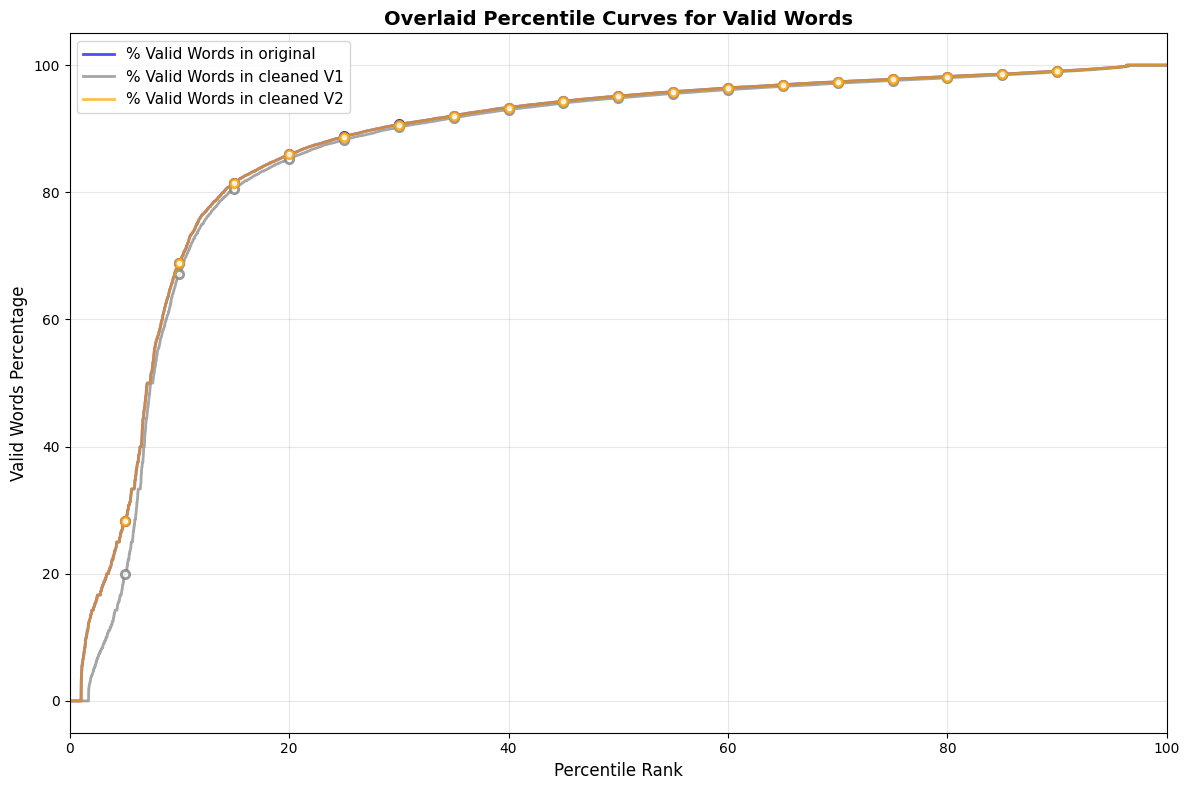

In [39]:
# PERCENTILE PLOTS 
# == PERC OF VALID WORDS ===
# Get the actual data from the DataFrame
og_data = df['% og_valid_words'].dropna().sort_values()
sc_v1_data = df['% sc_v1_valid_words'].dropna().sort_values()
sc_v2_data = df['% sc_v2_valid_words'].dropna().sort_values()

# Calculate percentiles for each dataset
percentiles_to_plot = np.arange(5, 95, 5)

# Create single plot instead of subplots
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

datasets = [
    (og_data, '% Valid Words in original', 'blue'),
    (sc_v1_data, '% Valid Words in cleaned V1', 'gray'),
    (sc_v2_data, '% Valid Words in cleaned V2', 'orange')
]

for data, label, color in datasets:
    # Create x-axis as percentile ranks
    x_percentiles = np.linspace(0, 100, len(data))
    
    # Plot the sorted data
    ax.plot(x_percentiles, data.values, color=color, alpha=0.7, linewidth=2, label=label)
    
    # Calculate and plot percentile markers
    percentile_values = np.percentile(data, percentiles_to_plot)
    
    # Plot percentile markers with same color but different marker
    ax.plot(percentiles_to_plot, percentile_values, 'o', color=color, markersize=6, 
            markerfacecolor='white', markeredgecolor=color, markeredgewidth=2,
            alpha=0.8)

# Customize the plot

ax.set_xlabel("Percentile Rank", fontsize=12)
ax.set_ylabel("Valid Words Percentage", fontsize=12)
ax.set_title("Overlaid Percentile Curves for Valid Words", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()



In [40]:
# Separate out rows based on criteria
# num_sep = rows with % num D_{dataset[0:3]}_raw tr > 50, at least 2 valid word found from original transcript, and at least 1 word with greater than 3 characters
num_sep = df[
    (df[f"% num D_{dataset[0:3]}_raw tr"] > 50) &
    (df[f'number_words_gt_3'] > 0)
]
post_num_sep_df = df[
    (df[f"% num D_{dataset[0:3]}_raw tr"] <= 50) |
    (df[f'number_words_gt_3'] == 0)
]

# r1 = rows with og_valid_words_alphachars_percentage < 50
r1 = post_num_sep_df[
    (post_num_sep_df['og_valid_words_alphachars_percentage'] < 50) 
]
post_r1_df = post_num_sep_df[
    (post_num_sep_df['og_valid_words_alphachars_percentage'] >= 50) 
]
# r2 = rows with og_valid_word_count <= 1
r2 = post_r1_df[
	(post_r1_df['number_words_gt_3'] <= 1)   
]
valid = post_r1_df[
	(post_r1_df['number_words_gt_3'] > 1)   
]

# combine problem rows
problem = pd.concat([r2, r1], ignore_index=True)

# print 
num_sep_count = len(num_sep)
print(f"Len num_sep: {num_sep_count}")
print(f"Len r1 - alpha_char_thresh: {len(r1)}")
print(f"Len r2 - word_count_thresh: {len(r2)}")
print(f"Len problem: {len(problem)}")
print(f"Len valid: {len(valid)}")

Len num_sep: 9
Len r1 - alpha_char_thresh: 872
Len r2 - word_count_thresh: 24
Len problem: 896
Len valid: 10333


In [41]:

# METRICS COLLECTION
# num_sep (print top 2, middle two, bottom 2 rows by % num D_{dataset[0:3]}_raw tr, with the count), print original transcript with them
num_sep_sorted = num_sep.sort_values(by=f'% num D_{dataset[0:3]}_raw tr', ascending=False)
print(f"\nTop 2 num_sep rows by % num D_{dataset[0:3]}_raw tr:")
print(num_sep_sorted[[f'% num D_{dataset[0:3]}_raw tr', 'number_words_gt_3', "CONTENTdm number"]].head(2))
print(f"\nMiddle 2 num_sep rows by % num D_{dataset[0:3]}_raw tr:")
middle_index = len(num_sep_sorted) // 2
print(num_sep_sorted[[f'% num D_{dataset[0:3]}_raw tr', 'number_words_gt_3', "CONTENTdm number"]].iloc[middle_index-1:middle_index+1])
print(f"\nBottom 2 num_sep rows by % num D_{dataset[0:3]}_raw tr:")
print(num_sep_sorted[[f'% num D_{dataset[0:3]}_raw tr', 'number_words_gt_3', "CONTENTdm number"]].tail(2))

# og_valid_words_alphachars_percentage
r1_sorted = r1.sort_values(by='og_valid_words_alphachars_percentage', ascending=False)
print("\nTop 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:")
print(r1_sorted[['og_valid_words_alphachars_percentage', 'number_words_gt_3', "CONTENTdm number"]].head(2))
print("\nMiddle 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:")
middle_index = len(r1_sorted) // 2
print(r1_sorted[['og_valid_words_alphachars_percentage', 'number_words_gt_3', "CONTENTdm number"]].iloc[middle_index-1:middle_index+1])
print("\nBottom 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:")
print(r1_sorted[['og_valid_words_alphachars_percentage', 'number_words_gt_3', "CONTENTdm number"]].tail(2))

# # number_words_gt_3
# r2_sorted = r2.sort_values(by='number_words_gt_3', ascending=False)
# print("\nTop 2 num_sep rows by number_words_gt_3:")
# print(r2_sorted[['number_words_gt_3', 'og_valid_words_alphachars_percentage', "CONTENTdm number"]].head(2))
# print("\nMiddle 2 num_sep rows by number_words_gt_3:")
# middle_index = len(r2_sorted) // 2
# print(r2_sorted[['number_words_gt_3', 'og_valid_words_alphachars_percentage', "CONTENTdm number"]].iloc[middle_index-1:middle_index+1])
# print("\nBottom 2 num_sep rows by number_words_gt_3:")
# print(r2_sorted[['number_words_gt_3', 'og_valid_words_alphachars_percentage', "CONTENTdm number"]].tail(2))



Top 2 num_sep rows by % num D_sim_raw tr:
      % num D_sim_raw tr  number_words_gt_3  CONTENTdm number
5218           78.074866                  2            5769.0
6954           73.324397                 22            7545.0

Middle 2 num_sep rows by % num D_sim_raw tr:
      % num D_sim_raw tr  number_words_gt_3  CONTENTdm number
2005           55.780933                 39            2476.0
2061           55.089059                 30            2532.0

Bottom 2 num_sep rows by % num D_sim_raw tr:
      % num D_sim_raw tr  number_words_gt_3  CONTENTdm number
2058           51.321586                 40            2529.0
2060           51.000000                 39            2531.0

Top 2 valid_words_alphachars rows by og_valid_words_alphachars_percentage:
      og_valid_words_alphachars_percentage  number_words_gt_3  \
7869                             49.699800                 87   
3933                             49.639423                 48   

      CONTENTdm number  
7869      

In [42]:
data_check = df[
    (df['sc_v1_valid_words_alphachars_percentage'] < 50) |
    (df['sc_v1_valid_word_count'] <= 1)   
]
data_check = data_check[['CONTENTdm file name', 'Original Transcript']]

data_check_2 = df[
    (df['sc_v2_valid_words_alphachars_percentage'] < 50) |
    (df['sc_v2_valid_word_count'] <= 1)   
]
data_check_2 = data_check_2[['CONTENTdm file name', 'Original Transcript']]

# less than 50 on og_valid_words_alphachars_percentage is def bad
print("problem len:", len(problem))

problem['text'] = problem['Original Transcript']

check = problem[['CONTENTdm file name', 'text', sc_tr_v2, 'og_valid_words', 'sc_v2_valid_words', '% og_valid_words', '% sc_v2_valid_words']]
print("main problematic examples:")
display(check)

print("data check v1 (sc_v1_valid_words_alphachars_percentage < 50):")
display(data_check)
print("data check v2 (sc_v2_valid_words_alphachars_percentage < 50):")
display(data_check_2)


problem len: 896
main problematic examples:


,CONTENTdm file name,text,D_sim_cleaned_v2,og_valid_words,sc_v2_valid_words,% og_valid_words,% sc_v2_valid_words
0,490.jp2,I'll get you yet.,I'll get you yet.,"[get, you, yet]","[get, you, yet]",75.000000,75.000000
1,496.jp2,Galatea,Galatea,[galatea],[galatea],100.000000,100.000000
2,743.jp2,POCKET PAL,POCKET PAL,"[pocket, pal]","[pocket, pal]",100.000000,100.000000
3,1075.jp2,"#''/' &gt;.-Â»""Â» ^waser:","#''/' >.- "" ^waser:",[waser],[waser],50.000000,50.000000
4,1096.jp2,"^iÂ£Â£~""^ As-","^i ~""^ As-",[as],[as],100.000000,100.000000
...,...,...,...,...,...,...,...
891,13839.jp2,CD is Â© .08 Cfl,CD is\n.08 Cfl,[is],[is],33.333333,33.333333
892,13846.jp2,0) (/&gt; tN tn ^ C8 Q CO in s s 4-...,0) (/> tN tn ^ C8 Q CO in s s 4-1 -= **l,"[co, in]","[co, in]",40.000000,40.000000
893,13855.jp2,1^^^^^ 3 â€¢4 ta* f&gt;. Â»' s aiiipa Â» ...,1^^^^^ 3 4 ta* f>. ' s aiiipa a\n8. o I\n2o| S...,"[ta, co, si, mi, as, if, hi, si, is, in, go, i...","[ta, co, si, mi, as, if, hi, si, is, in, go, i...",44.660194,44.660194
894,13856.jp2,4) 4&gt; 4&gt; Q) +Â»&gt; SS o Â£ &gt; ...,4) 4> 4> Q) + > SS o > i o Sl TJ\nUl\nS.\nIA -...,"[to, it, si, as, is, lie, co, fill]","[to, it, si, as, is, lie, co, fill]",23.529412,23.529412


data check v1 (sc_v1_valid_words_alphachars_percentage < 50):


,CONTENTdm file name,Original Transcript
87,496.jp2,Galatea
146,567.jp2,â€¢ 4*yy/'y&?/fy&
158,579.jp2,**&' 3y&gt;-y/ 53 AC^H^AAr'Ai^ t^A-A: â– *L...
163,584.jp2,A^^A^y^*' ^A /*% A ' &gt;/ â€”a y? A...
171,592.jp2,{l)'t iAL*. *** A AC^^J f p /AAuLo ...
...,...,...
11185,13846.jp2,0) (/&gt; tN tn ^ C8 Q CO in s s 4-...
11194,13855.jp2,1^^^^^ 3 â€¢4 ta* f&gt;. Â»' s aiiipa Â» ...
11195,13856.jp2,4) 4&gt; 4&gt; Q) +Â»&gt; SS o Â£ &gt; ...
11196,13858.jp2,"0- Â«**t ""8 si i tf5 i j 5"


data check v2 (sc_v2_valid_words_alphachars_percentage < 50):


,CONTENTdm file name,Original Transcript
87,496.jp2,Galatea
146,567.jp2,â€¢ 4*yy/'y&?/fy&
158,579.jp2,**&' 3y&gt;-y/ 53 AC^H^AAr'Ai^ t^A-A: â– *L...
163,584.jp2,A^^A^y^*' ^A /*% A ' &gt;/ â€”a y? A...
171,592.jp2,{l)'t iAL*. *** A AC^^J f p /AAuLo ...
...,...,...
11185,13846.jp2,0) (/&gt; tN tn ^ C8 Q CO in s s 4-...
11194,13855.jp2,1^^^^^ 3 â€¢4 ta* f&gt;. Â»' s aiiipa Â» ...
11195,13856.jp2,4) 4&gt; 4&gt; Q) +Â»&gt; SS o Â£ &gt; ...
11196,13858.jp2,"0- Â«**t ""8 si i tf5 i j 5"


In [ ]:
path = f"../data/{dataset}/split_data/h2_split"
if not os.path.exists(path):
    os.makedirs(path, exist_ok=True)

save_csv(problem, f"{path}/D_{dataset[0:3]}_h2_bad.csv")
save_csv(num_sep, f"{path}/D_{dataset[0:3]}_h2_nums.csv")
save_csv(valid, f"{path}/D_{dataset[0:3]}_h2_main.csv")

# find columns where valid words are different between og and v2
diff_valid_words = df[
    (df['og_valid_words'] != df['sc_v2_valid_words'])
]
# create list of which words differ
def list_diff_words(row):
    og_set = set(row['og_valid_words'])
    sc_set = set(row['sc_v2_valid_words'])
    diff_words = og_set.symmetric_difference(sc_set)
    return list(diff_words)

diff_valid_words['diff_valid_words'] = diff_valid_words.apply(list_diff_words, axis=1)
diff_valid_words = diff_valid_words[['CONTENTdm file name', "Reference URL", 'diff_valid_words', 'og_valid_words', 'sc_v2_valid_words', 'og_not_words', 'sc_v2_not_words', 'Original Transcript', sc_tr_v2]]
save_csv(diff_valid_words, f"D_{dataset[0:3]}_h2_diff_valid_words.csv")

/tmp/ipykernel_285174/1188668382.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diff_valid_words['diff_valid_words'] = diff_valid_words.apply(list_diff_words, axis=1)


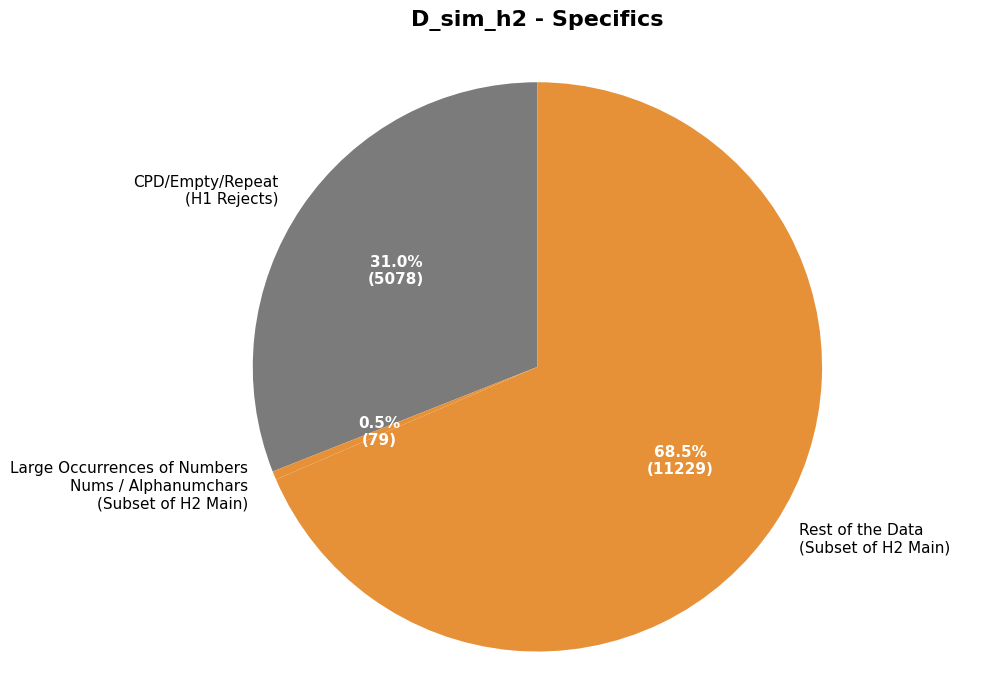

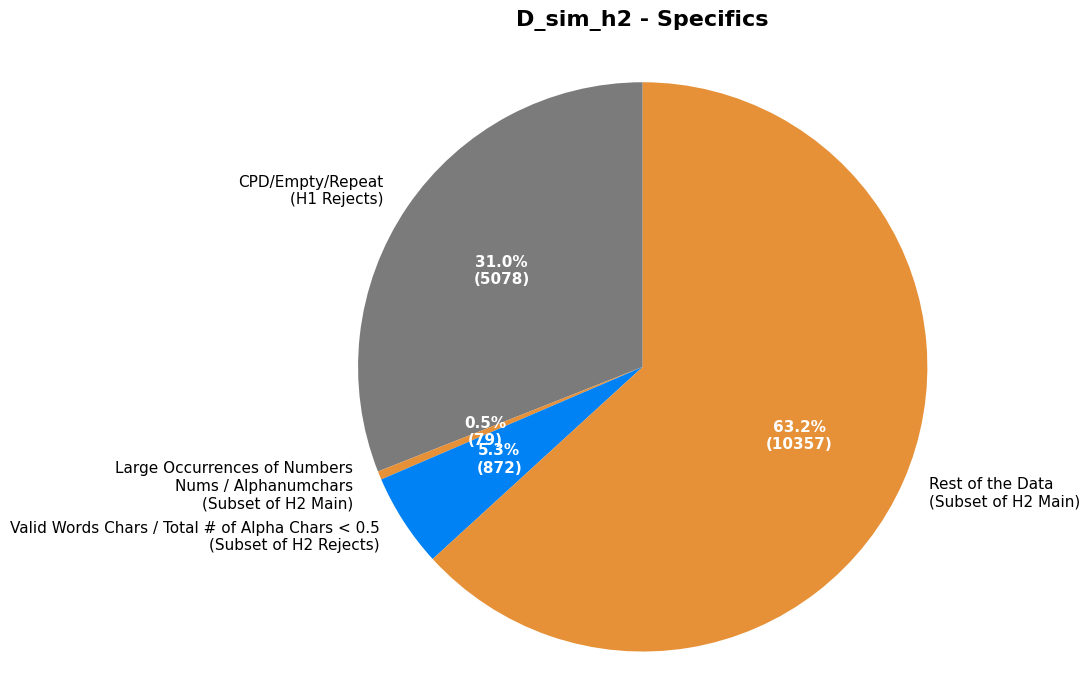

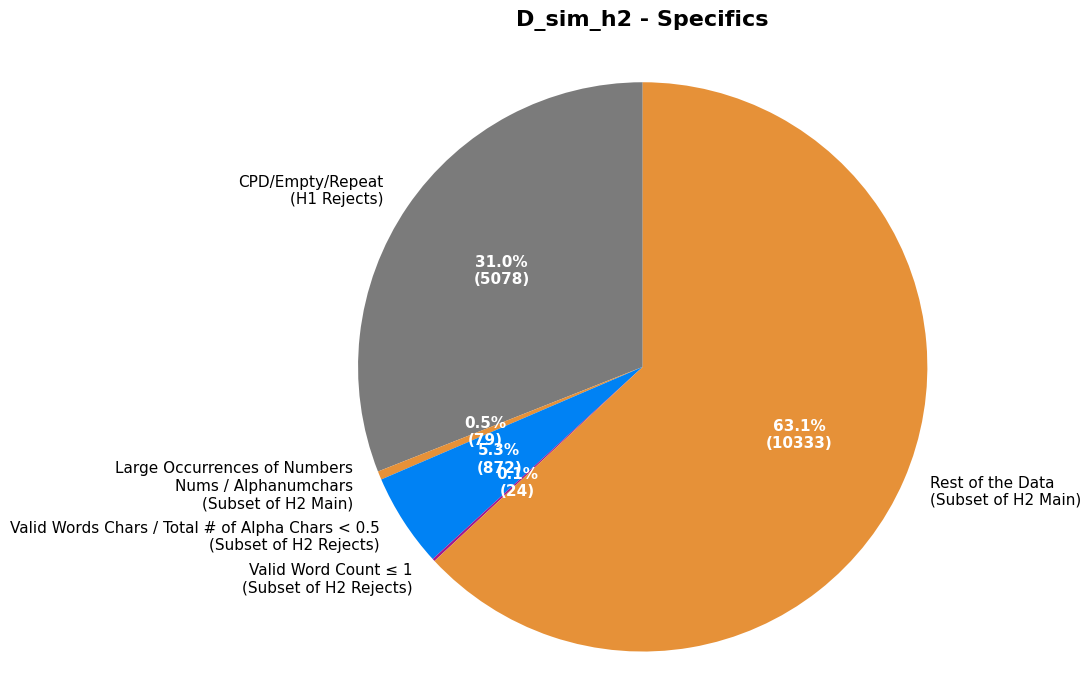

In [44]:
# round 1 = H1
# round 2 pie chart
round_one_iso = 5078 # gray
# num_sep_r = num_sep_count  
num_sep_r = 79  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) + r2_part_2 + r2_part_1  # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Subset of H2 Main)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, rest]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', '#e69138'],
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()

# round 4 pie chart

# round 3 pie chart
round_one_iso = 5078 # gray
# num_sep_r = num_sep_count  
num_sep_r = 79  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) + r2_part_2  # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Subset of H2 Main)', 'Valid Words Chars / Total # of Alpha Chars < 0.5\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, r2_part_1, rest]

fig, ax = plt.subplots(figsize=(10, 7))
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', "#0082f4", '#e69138'],
    textprops={'fontsize': 11}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)
ax.axis('equal')
plt.tight_layout()

# round 4 pie chart

# Counts
round_one_iso = 5078 # gray
# num_sep_r = num_sep_count  
num_sep_r = 79  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Large Occurrences of Numbers\nNums / Alphanumchars\n(Subset of H2 Main)', 'Valid Words Chars / Total # of Alpha Chars < 0.5\n(Subset of H2 Rejects)', 'Valid Word Count ≤ 1\n(Subset of H2 Rejects)', 'Rest of the Data\n(Subset of H2 Main)']
values = [round_one_iso, num_sep_r, r2_part_1, r2_part_2, rest]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", '#e69138', "#0082f4", "#a11a8f", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title(f'D_{dataset[0:3]}_h2 - Specifics', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

plt.tight_layout()


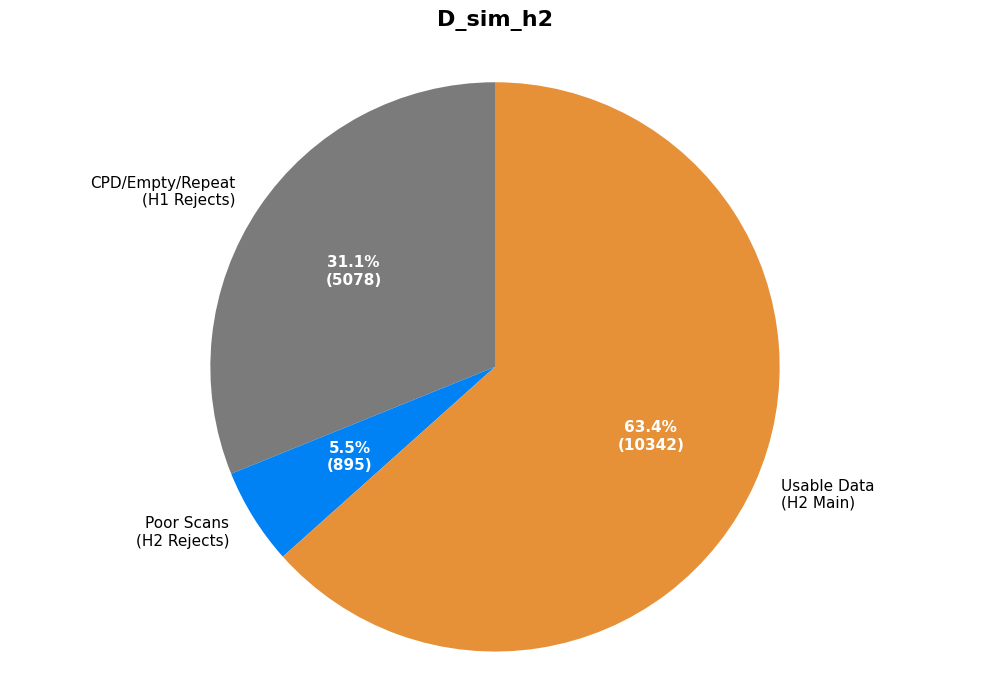

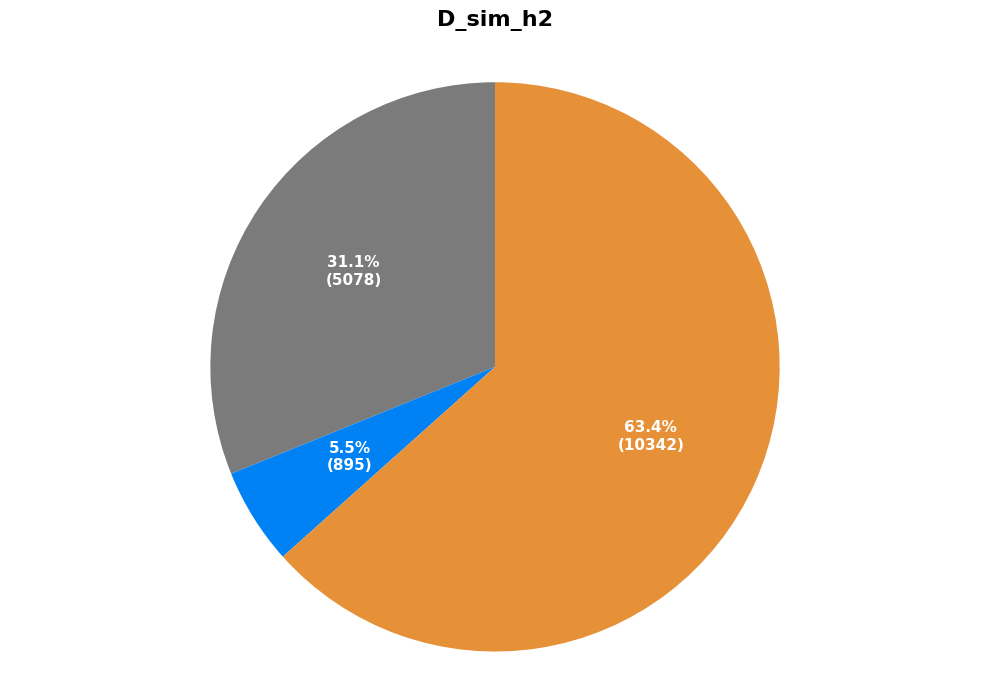

In [45]:
# MAIN VERSION
# Counts
round_one_iso = 5078 # gray
num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Poor Scans\n(H2 Rejects)', 'Usable Data\n(H2 Main)']
values = [round_one_iso, r2_part_1 + r2_part_2, rest+num_sep_r]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    labels=categories,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", "#0082f4", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title(f'D_{dataset[0:3]}_h2', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

# p1 = mpatches.Patch(color="#0082f4", label='Pertains to raw transcript metrics')
# plt.legend(handles=[p1], loc='center right', bbox_to_anchor=(-0.05, 0))
plt.tight_layout()

# VERSION WITHOUT CATEGORY LABELS
# Counts
round_one_iso = 5078 # gray
num_sep_r = num_sep_count  
r2_part_1 = len(r1)
r2_part_2 = len(r2)
rest = len(valid) # orange

# data
categories = ['CPD/Empty/Repeat\n(H1 Rejects)', 'Poor Scans\n(H2 Rejects)', 'Usable Data\n(H2 Main)']
values = [round_one_iso, r2_part_1 + r2_part_2, rest+num_sep_r]

# Create pie chart
fig, ax = plt.subplots(figsize=(10, 7))

# Create the pie chart with customizations
wedges, texts, autotexts = ax.pie(
    values,
    autopct=lambda pct: f'{pct:.1f}%\n({int(pct/100.*sum(values))})',  # Show percentages and counts
    startangle=90,       # Start from top
    colors=["#7b7b7b", "#0082f4", '#e69138'],
    textprops={'fontsize': 11}
)

# Enhance the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add title
plt.title(f'D_{dataset[0:3]}_h2', fontsize=16, fontweight='bold', pad=20)

# Equal aspect ratio ensures circular pie
ax.axis('equal')

# p1 = mpatches.Patch(color="#0082f4", label='Pertains to raw transcript metrics')
# plt.legend(handles=[p1], loc='center right', bbox_to_anchor=(-0.05, 0))
plt.tight_layout()


In [47]:
path = f"../data/{dataset}/split_data/h2_split/training/"
if not os.path.exists(path):
    os.makedirs(path, exist_ok=True)

# combine num_sep and main into one
combined = pd.concat([valid, num_sep], ignore_index=True)
print(f"Len combined: {len(combined)}")
save_csv(combined, f"{path}/D_{dataset[0:3]}_h2_main+nums.csv")

Len combined: 10342


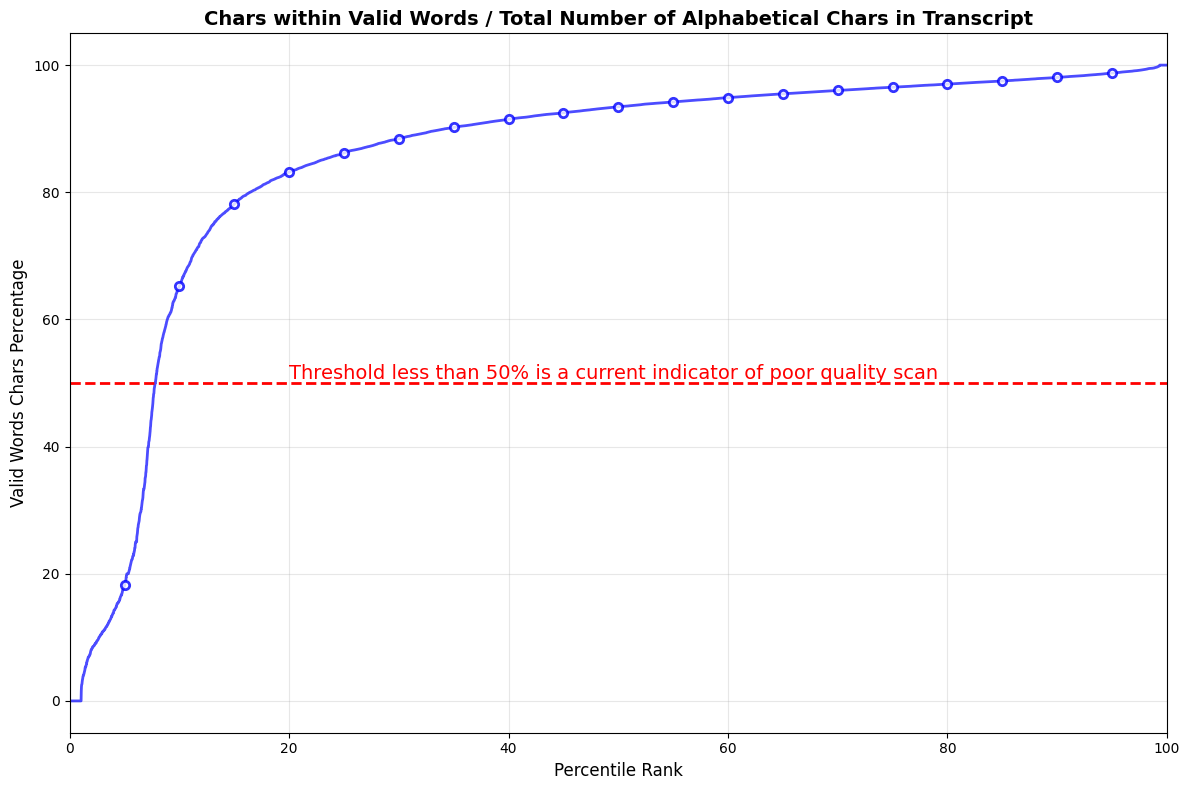

Top 2 rows with lowest number_words_gt_3:


,Title,Date,Source,Description,Digital Collection,Contributing Institution,Rights,Reference URL,CONTENTdm number,CONTENTdm file name,...,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_alpha_count,og_valid_words_alphachars_percentage,sc_v1_alpha_count,sc_v1_valid_words_alphachars_percentage,sc_v2_alpha_count,sc_v2_valid_words_alphachars_percentage
813,"Letter from a friend, Page 1",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,1257.0,1361.jp2,...,100.0,66.666667,66.666667,66.666667,2,100.0,2,100.0,2,100.0
4320,"Brochure entitled """"Victory in Mississippi"""", ...",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,4848.0,5158.jp2,...,100.0,37.500000,37.500000,50.000000,8,75.0,8,75.0,8,75.0


Middle 2 rows:


,Title,Date,Source,Description,Digital Collection,Contributing Institution,Rights,Reference URL,CONTENTdm number,CONTENTdm file name,...,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_alpha_count,og_valid_words_alphachars_percentage,sc_v1_alpha_count,sc_v1_valid_words_alphachars_percentage,sc_v2_alpha_count,sc_v2_valid_words_alphachars_percentage
9644,"Proxy statement of T. R. McConnell, Page 4",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,10282.0,11492.jp2,...,99.227799,91.985203,92.041949,91.985203,1515,98.481848,1515,98.481848,1515,98.481848
9050,"UNAVA news - Ebony editorial, May, 1946, Page 1",NaN,NaN,NaN,NaN,NaN,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,9676.0,10811.jp2,...,95.053004,88.425926,88.837209,88.543046,1432,93.365922,1432,93.365922,1432,93.365922


Bottom 2 rows with highest number_words_gt_3:


,Title,Date,Source,Description,Digital Collection,Contributing Institution,Rights,Reference URL,CONTENTdm number,CONTENTdm file name,...,% sc_v2_valid_words,og_valid_words_char_percentage,sc_v1_valid_words_chars_percentage,sc_v2_valid_words_chars_percentage,og_alpha_count,og_valid_words_alphachars_percentage,sc_v1_alpha_count,sc_v1_valid_words_alphachars_percentage,sc_v2_alpha_count,sc_v2_valid_words_alphachars_percentage
10329,"Newspaper clipping from The Pee Dee Herald, ""T...",1971-04-08 00:00:00,NaN,NaN,"Modjeska Simkins Papers, 1909-1992",University of South Carolina. South Carolina P...,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,11607.0,12967.jp2,...,96.667412,91.597104,92.212693,91.788656,22529,95.463625,22488,95.624333,22525,95.480577
10541,"Publication from Minneapolis Morning Tribune, ...",1953-12,NaN,NaN,"Modjeska Simkins Papers, 1909-1992",University of South Carolina. South Carolina P...,Copyright Not Evaluated. For further informati...,http://cdm17173.contentdm.oclc.org/cdm/ref/col...,11820.0,13180.jp2,...,96.052632,88.768832,89.160312,89.085780,21553,93.768849,21544,93.348496,21549,93.786255


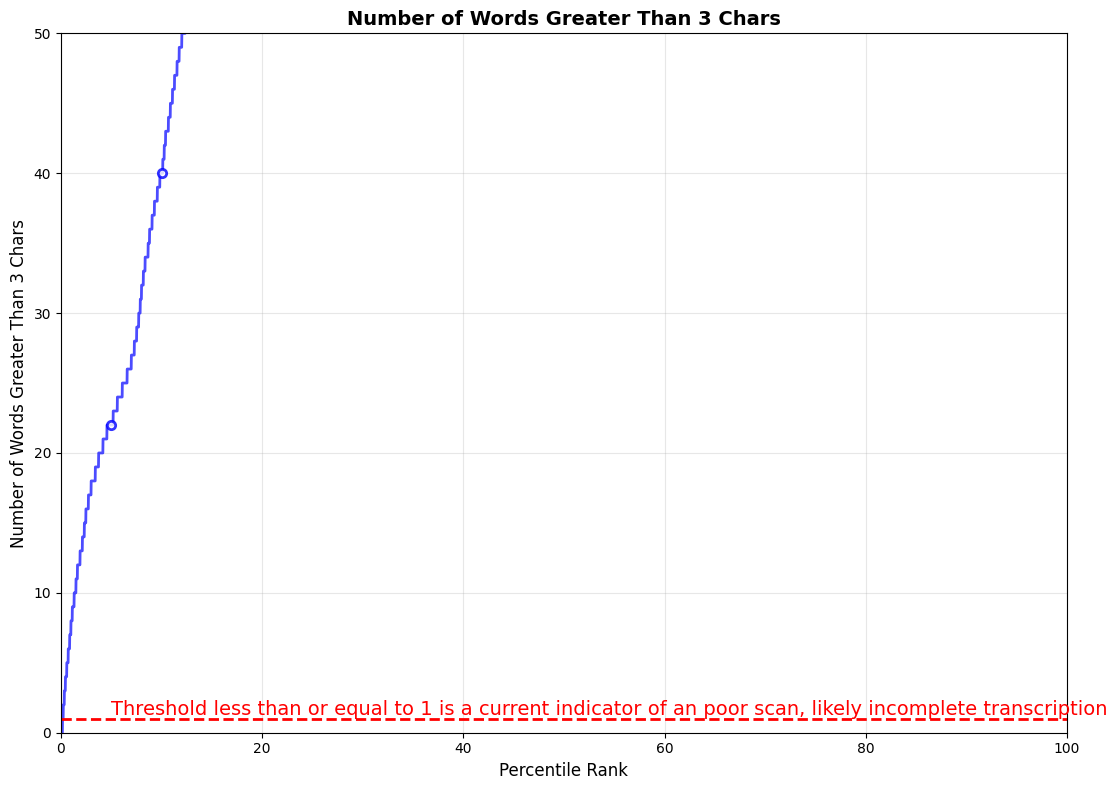

In [48]:
def create_percentile_plot_single(df, col, title, y_label, color, y_intercept, y_intercept_label=None, max_value=None, location_for_y_label=20):
    og_data = df[col].dropna().sort_values()

    # Calculate percentiles for each dataset
    percentiles_to_plot = np.arange(5, 100, 5)

    # Create single plot instead of subplots
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    # Plot the sorted data
    ax.plot(np.linspace(0, 100, len(og_data)), og_data.values, color=color, alpha=0.7, linewidth=2, label=label)
    # Calculate and plot percentile markers
    percentile_values = np.percentile(og_data, percentiles_to_plot)
    # Plot percentile markers with same color but different marker
    ax.plot(percentiles_to_plot, percentile_values, 'o', color='blue', markersize
        =6, markerfacecolor='white', markeredgecolor='blue', markeredgewidth=2,
        alpha=0.8)
    # Customize the plot
    ax.set_xlabel("Percentile Rank", fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    plt.axhline(y=y_intercept, color='red', linestyle='--', linewidth=2)
    if y_intercept_label:
        plt.text(location_for_y_label, y_intercept, y_intercept_label, color='red', fontsize=14, va='bottom', ha='left')
    if max_value:
        ax.set_ylim(0, max_value)
    ax.grid(True, alpha=0.3)
    # ax.legend(fontsize=11)
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()


create_percentile_plot_single(df, 'og_valid_words_alphachars_percentage', 'Chars within Valid Words / Total Number of Alphabetical Chars in Transcript', 'Valid Words Chars Percentage', 'blue', 50, y_intercept_label='Threshold less than 50% is a current indicator of poor quality scan')

check = df[
    (df['og_valid_words_alphachars_percentage'] >= 50)
]

# sort check by number_words_gt_3 ascending
check = check.sort_values(by='number_words_gt_3', ascending=True)
# print top 2, middle 2, bottom 2
print("Top 2 rows with lowest number_words_gt_3:")
display(check.head(2))
middle_index = len(check) // 2
print("Middle 2 rows:")
display(check.iloc[middle_index-1:middle_index+1])
print("Bottom 2 rows with highest number_words_gt_3:")
display(check.tail(2))

create_percentile_plot_single(check, 'number_words_gt_3', 'Number of Words Greater Than 3 Chars', 'Number of Words Greater Than 3 Chars', 'blue', 1, max_value=50, y_intercept_label='Threshold less than or equal to 1 is a current indicator of an poor scan, likely incomplete transcription', location_for_y_label=5)